In [125]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from imblearn.over_sampling import SMOTE

In [126]:
df = pd.read_csv("vista_modelo", index_col=0)

In [127]:
df

,entrega_tardia,dia_semana_compra,mes_compra,plazo_prometido_dias,customer_state,seller_state,mismo_estado,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name,product_category_name_english,payment_type,payment_installments,num_items_pedido
order_id,,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,0,3,9,16,RJ,SP,0,58.90,13.29,650.0,28.0,9.0,14.0,cool_stuff,cool_stuff,credit_card,2.0,1
00018f77f2f0320c557190d7a144bdd3,0,3,4,19,SP,SP,1,239.90,19.93,30000.0,50.0,30.0,40.0,pet_shop,pet_shop,credit_card,3.0,1
000229ec398224ef6ca0657da4fc703e,0,0,1,22,MG,MG,1,199.00,17.87,3050.0,33.0,13.0,33.0,moveis_decoracao,furniture_decor,credit_card,5.0,1
00024acbcdf0a6daa1e931b038114c75,0,3,8,12,SP,SP,1,12.99,12.79,200.0,16.0,10.0,15.0,perfumaria,perfumery,credit_card,2.0,1
00042b26cf59d7ce69dfabb4e55b4fd9,0,6,2,41,SP,PR,0,199.90,18.14,3750.0,35.0,40.0,30.0,ferramentas_jardim,garden_tools,credit_card,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc94f6ce00a00581880bf54a75a037,0,1,4,25,MA,SC,0,299.99,43.41,10150.0,89.0,15.0,40.0,utilidades_domesticas,housewares,boleto,1.0,1
fffcd46ef2263f404302a634eb57f7eb,0,6,7,18,PR,SP,0,350.00,36.53,8950.0,45.0,26.0,38.0,informatica_acessorios,computers_accessories,boleto,1.0,1
fffce4705a9662cd70adb13d4a31832d,0,1,10,18,SP,PR,0,99.90,16.95,967.0,21.0,24.0,19.0,esporte_lazer,sports_leisure,credit_card,3.0,1


In [128]:
df.isna().sum()

entrega_tardia                      0
dia_semana_compra                   0
mes_compra                          0
plazo_prometido_dias                0
customer_state                      0
seller_state                        0
mismo_estado                        0
price                               0
freight_value                       0
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name            1559
product_category_name_english    1559
payment_type                        3
payment_installments                3
num_items_pedido                    0
dtype: int64

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   entrega_tardia                 110189 non-null  int64  
 1   dia_semana_compra              110189 non-null  int64  
 2   mes_compra                     110189 non-null  int64  
 3   plazo_prometido_dias           110189 non-null  int64  
 4   customer_state                 110189 non-null  object 
 5   seller_state                   110189 non-null  object 
 6   mismo_estado                   110189 non-null  int64  
 7   price                          110189 non-null  float64
 8   freight_value                  110189 non-null  float64
 9   product_weight_g               110171 non-null  float64
 10  product_length_cm              110171 non-null  float64
 11  product_height_cm              110171 n

In [130]:
columnas_numericas = df.select_dtypes(include='number').columns.tolist()


In [131]:
imputer = KNNImputer(n_neighbors=5)
df_num_imputado = pd.DataFrame(
    imputer.fit_transform(df[columnas_numericas]), 
    columns=columnas_numericas,
    index=df.index
)



In [132]:
df_limpio = df.copy()
df_limpio[columnas_numericas] = df_num_imputado


In [133]:
df_limpio.isna().sum()

entrega_tardia                      0
dia_semana_compra                   0
mes_compra                          0
plazo_prometido_dias                0
customer_state                      0
seller_state                        0
mismo_estado                        0
price                               0
freight_value                       0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_category_name            1559
product_category_name_english    1559
payment_type                        3
payment_installments                0
num_items_pedido                    0
dtype: int64

In [134]:
df_limpio['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table               10953
health_beauty                 9465
sports_leisure                8430
furniture_decor               8160
computers_accessories         7643
                             ...  
arts_and_craftmanship           24
cds_dvds_musicals               14
la_cuisine                      14
fashion_childrens_clothes        7
security_and_services            2
Name: count, Length: 71, dtype: int64

In [135]:
df_limpio['product_category_name_english'] = df_limpio['product_category_name_english'].fillna('sin_categoria')

In [136]:
df_limpio = df_limpio.drop(columns=['product_category_name'])
df_limpio['payment_type'] = df_limpio['payment_type'].fillna('sin_categoria')

In [137]:
df_limpio.isna().sum()

entrega_tardia                   0
dia_semana_compra                0
mes_compra                       0
plazo_prometido_dias             0
customer_state                   0
seller_state                     0
mismo_estado                     0
price                            0
freight_value                    0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
payment_type                     0
payment_installments             0
num_items_pedido                 0
dtype: int64

In [138]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   entrega_tardia                 110189 non-null  float64
 1   dia_semana_compra              110189 non-null  float64
 2   mes_compra                     110189 non-null  float64
 3   plazo_prometido_dias           110189 non-null  float64
 4   customer_state                 110189 non-null  object 
 5   seller_state                   110189 non-null  object 
 6   mismo_estado                   110189 non-null  float64
 7   price                          110189 non-null  float64
 8   freight_value                  110189 non-null  float64
 9   product_weight_g               110189 non-null  float64
 10  product_length_cm              110189 non-null  float64
 11  product_height_cm              110189 n

In [139]:
df['customer_state'].value_counts()

customer_state
SP    46441
RJ    14143
MG    12916
RS     6133
PR     5649
SC     4097
BA     3683
DF     2355
GO     2277
ES     2225
PE     1746
CE     1426
PA     1054
MT     1037
MS      811
MA      800
PB      586
PI      523
RN      521
AL      427
SE      375
TO      310
RO      273
AM      163
AC       91
AP       81
RR       46
Name: count, dtype: int64

In [140]:
le = LabelEncoder()
df_limpio['customer_state'] = le.fit_transform(df_limpio['customer_state'])

In [141]:

df_limpio['seller_state'] = le.fit_transform(df_limpio['seller_state'])

In [142]:
df_limpio['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table               10953
health_beauty                 9465
sports_leisure                8430
furniture_decor               8160
computers_accessories         7643
                             ...  
arts_and_craftmanship           24
cds_dvds_musicals               14
la_cuisine                      14
fashion_childrens_clothes        7
security_and_services            2
Name: count, Length: 72, dtype: int64

In [143]:


df_limpio['product_category_name_english'] = le.fit_transform(df_limpio['product_category_name_english'])

In [144]:
df_limpio

,entrega_tardia,dia_semana_compra,mes_compra,plazo_prometido_dias,customer_state,seller_state,mismo_estado,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_type,payment_installments,num_items_pedido
order_id,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,0.0,3.0,9.0,16.0,18,21,0.0,58.90,13.29,650.0,28.0,9.0,14.0,20,credit_card,2.0,1.0
00018f77f2f0320c557190d7a144bdd3,0.0,3.0,4.0,19.0,25,21,1.0,239.90,19.93,30000.0,50.0,30.0,40.0,60,credit_card,3.0,1.0
000229ec398224ef6ca0657da4fc703e,0.0,0.0,1.0,22.0,10,7,1.0,199.00,17.87,3050.0,33.0,13.0,33.0,39,credit_card,5.0,1.0
00024acbcdf0a6daa1e931b038114c75,0.0,3.0,8.0,12.0,25,21,1.0,12.99,12.79,200.0,16.0,10.0,15.0,59,credit_card,2.0,1.0
00042b26cf59d7ce69dfabb4e55b4fd9,0.0,6.0,2.0,41.0,25,14,0.0,199.90,18.14,3750.0,35.0,40.0,30.0,42,credit_card,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc94f6ce00a00581880bf54a75a037,0.0,1.0,4.0,25.0,9,19,0.0,299.99,43.41,10150.0,89.0,15.0,40.0,49,boleto,1.0,1.0
fffcd46ef2263f404302a634eb57f7eb,0.0,6.0,7.0,18.0,17,21,0.0,350.00,36.53,8950.0,45.0,26.0,38.0,15,boleto,1.0,1.0
fffce4705a9662cd70adb13d4a31832d,0.0,1.0,10.0,18.0,25,14,0.0,99.90,16.95,967.0,21.0,24.0,19.0,66,credit_card,3.0,1.0


In [145]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   entrega_tardia                 110189 non-null  float64
 1   dia_semana_compra              110189 non-null  float64
 2   mes_compra                     110189 non-null  float64
 3   plazo_prometido_dias           110189 non-null  float64
 4   customer_state                 110189 non-null  int64  
 5   seller_state                   110189 non-null  int64  
 6   mismo_estado                   110189 non-null  float64
 7   price                          110189 non-null  float64
 8   freight_value                  110189 non-null  float64
 9   product_weight_g               110189 non-null  float64
 10  product_length_cm              110189 non-null  float64
 11  product_height_cm              110189 n

In [146]:
df_limpio['payment_type'].value_counts()

payment_type
credit_card      82930
boleto           22362
voucher           3243
debit_card        1651
sin_categoria        3
Name: count, dtype: int64

In [147]:
df_limpio['payment_type']= le.fit_transform(df_limpio['payment_type'])

In [148]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   entrega_tardia                 110189 non-null  float64
 1   dia_semana_compra              110189 non-null  float64
 2   mes_compra                     110189 non-null  float64
 3   plazo_prometido_dias           110189 non-null  float64
 4   customer_state                 110189 non-null  int64  
 5   seller_state                   110189 non-null  int64  
 6   mismo_estado                   110189 non-null  float64
 7   price                          110189 non-null  float64
 8   freight_value                  110189 non-null  float64
 9   product_weight_g               110189 non-null  float64
 10  product_length_cm              110189 non-null  float64
 11  product_height_cm              110189 n

In [149]:
X = df_limpio

<Axes: >

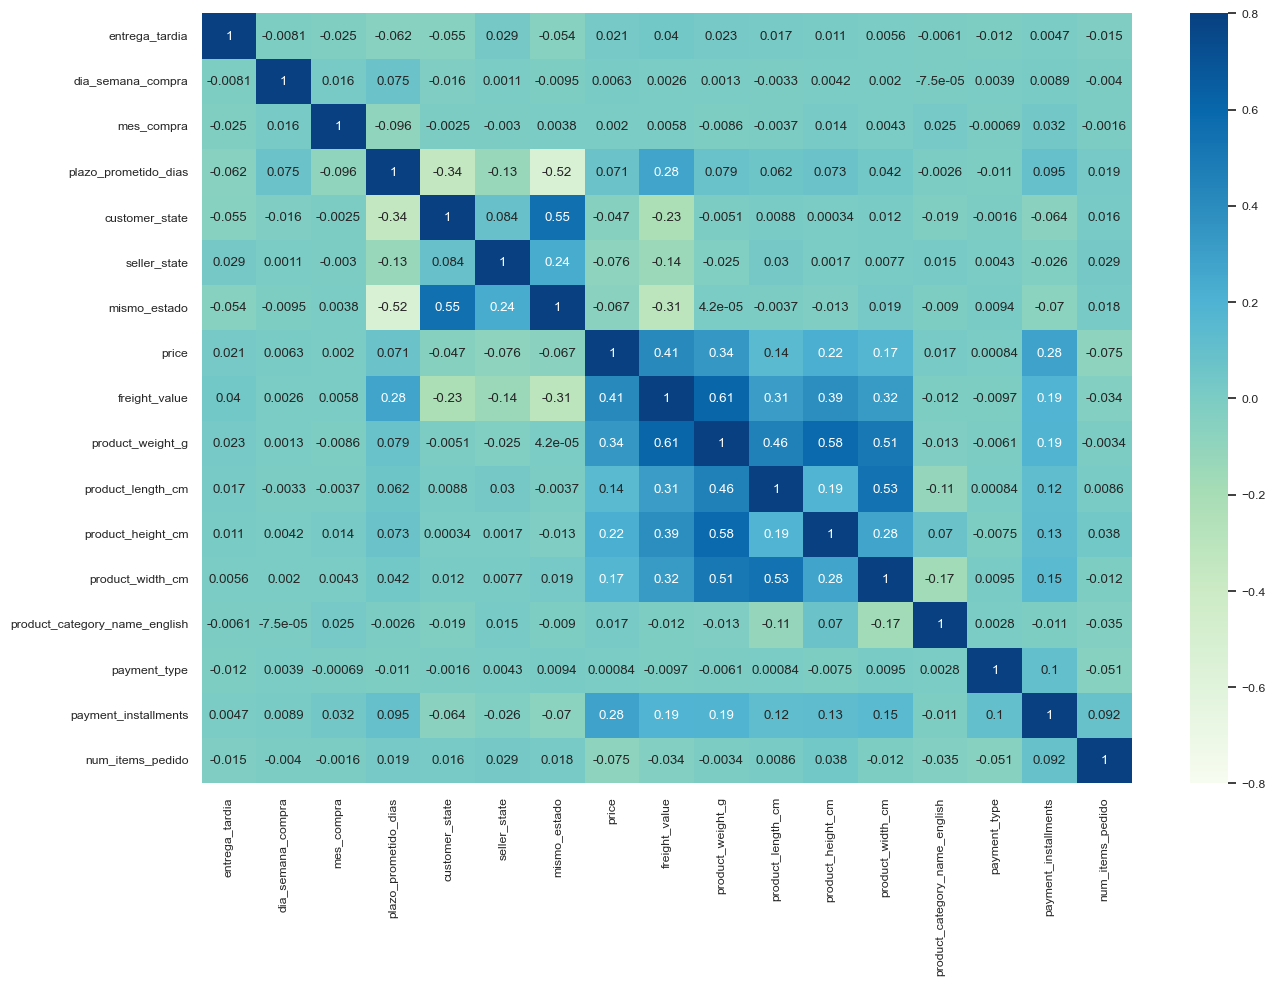

In [150]:
sns.set(style="whitegrid",font_scale=0.8)
plt.figure(figsize=(15,10))
sns.heatmap(X.corr(),annot=True,cmap="GnBu", vmin=-0.8,vmax=0.8)

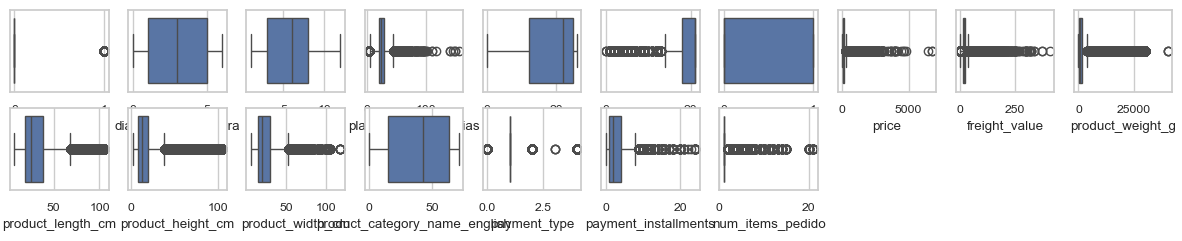

In [151]:
plt.figure(figsize=(15,10))
c = df_limpio.columns[:]
for i in enumerate(c):
    plt.subplot(8,10,i[0]+1)
    sns.boxplot(x=i[1],data=df_limpio)

In [152]:
for i in c:
  q1 = df_limpio[i].quantile(0.05)
  q4 = df_limpio[i].quantile(0.95)
  df_limpio[i][df_limpio[i] <= q1] = q1
  df_limpio[i][df_limpio[i] >= q4] = q4

C:\Users\dalz2\AppData\Local\Temp\ipykernel_19424\4292145109.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_limpio[i][df_limpio[i] <= q1] = q1
C:\Users\dalz2\AppData\Local\Temp\ipykernel_19424\4292145109.py:4: SettingWithCopyWarning:

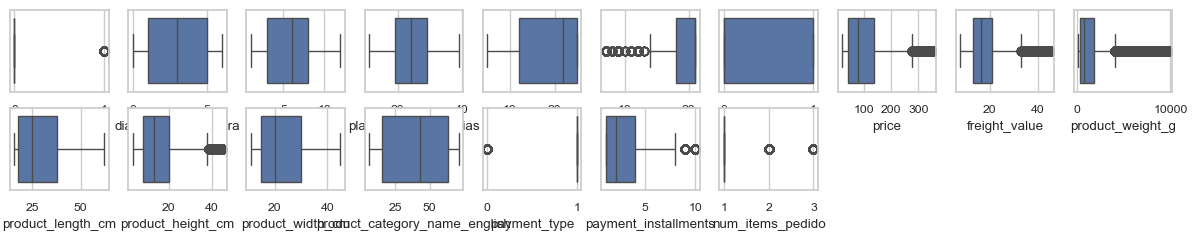

In [153]:
plt.figure(figsize=(15,10))
c = df_limpio.columns[:]
for i in enumerate(c):
    plt.subplot(8,10,i[0]+1)
    sns.boxplot(x=i[1],data=df_limpio)

array([[<Axes: title={'center': 'entrega_tardia'}>,
        <Axes: title={'center': 'dia_semana_compra'}>,
        <Axes: title={'center': 'mes_compra'}>,
        <Axes: title={'center': 'plazo_prometido_dias'}>],
       [<Axes: title={'center': 'customer_state'}>,
        <Axes: title={'center': 'seller_state'}>,
        <Axes: title={'center': 'mismo_estado'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'freight_value'}>,
        <Axes: title={'center': 'product_weight_g'}>,
        <Axes: title={'center': 'product_length_cm'}>,
        <Axes: title={'center': 'product_height_cm'}>],
       [<Axes: title={'center': 'product_width_cm'}>,
        <Axes: title={'center': 'product_category_name_english'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'payment_installments'}>],
       [<Axes: title={'center': 'num_items_pedido'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

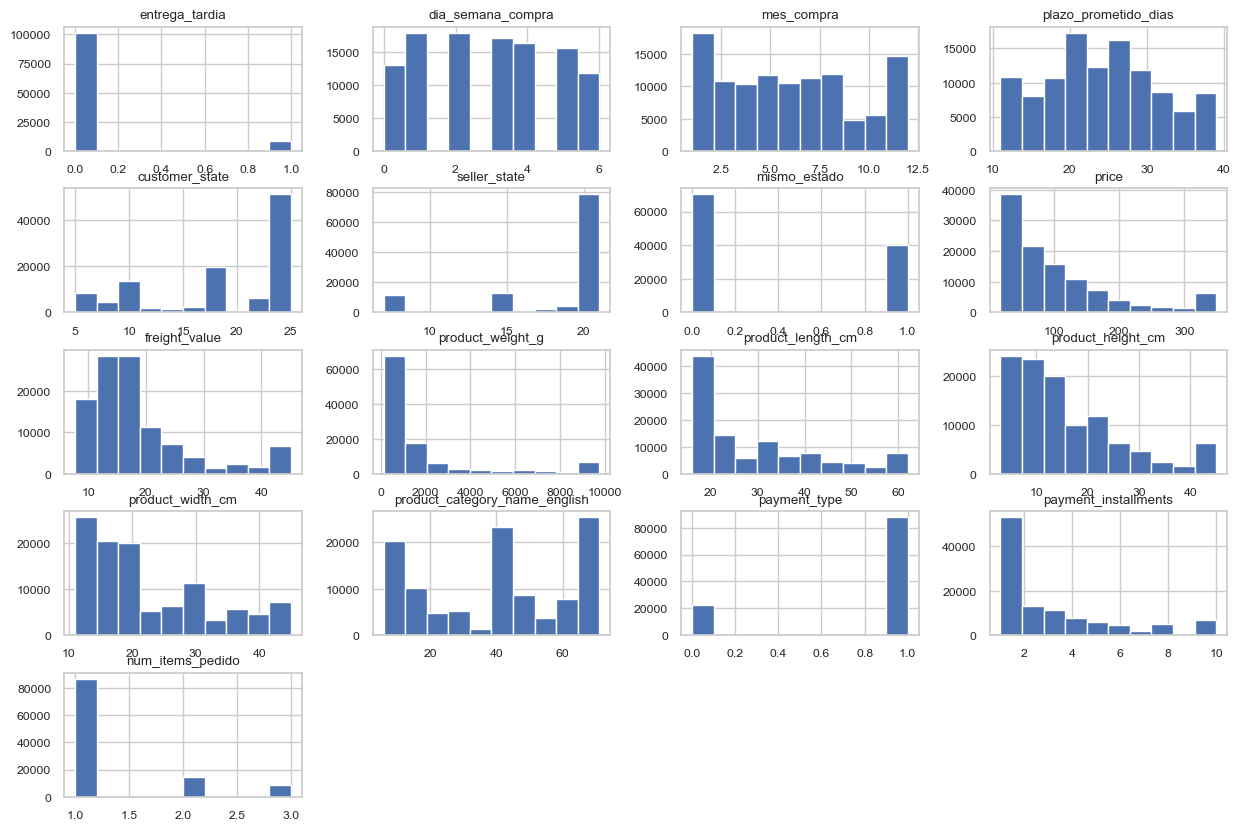

In [154]:
df_limpio.hist(figsize= (15,10))

In [155]:
X= df_limpio.drop('entrega_tardia', axis=1)
y= df_limpio['entrega_tardia']

In [156]:
y.value_counts()

entrega_tardia
0.0    101475
1.0      8714
Name: count, dtype: int64

In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1500, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [158]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

In [159]:
ann = Sequential()
ann.add(Dense(units=14,activation="relu"))
ann.add(Dense(units=6,activation="relu"))
ann.add(Dense(units=1, activation="sigmoid"))
ann.compile(optimizer="adam",loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_bal,y_train_bal,validation_data=(X_test_scaled,y_test), batch_size=1200,epochs=50)

Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5340 - loss: 0.6881 - val_accuracy: 0.6112 - val_loss: 0.6438
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5926 - loss: 0.6678 - val_accuracy: 0.5788 - val_loss: 0.6612
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6152 - loss: 0.6520 - val_accuracy: 0.6165 - val_loss: 0.6284
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6193 - loss: 0.6464 - val_accuracy: 0.5935 - val_loss: 0.6363
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6214 - loss: 0.6439 - val_accuracy: 0.5475 - val_loss: 0.6647
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6232 - loss: 0.6420 - val_accuracy: 0.5817 - val_loss: 0.6359
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6248 - loss: 0.6401 - val_accuracy: 0.5386 - val_loss: 0.6645
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6269 - loss: 0.6388 - val_accuracy: 0.

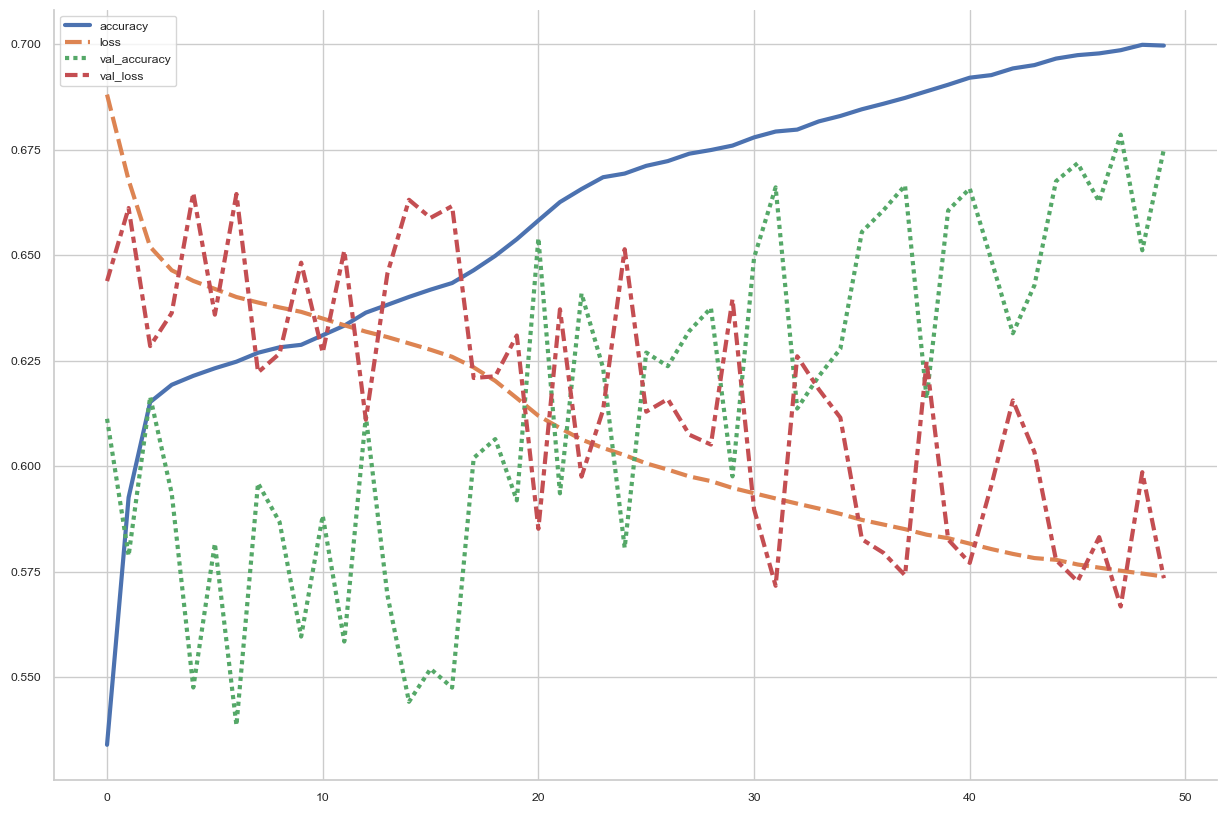

In [160]:
loss = pd.DataFrame(ann.history.history)
plt.figure(figsize=(15,10))
sns.lineplot(data=loss, lw=3)
sns.despine()